<a href="https://colab.research.google.com/github/WilliamJin123/betting/blob/main/research/stock_market_manifold_testing/Stock_Market_Manifold_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Temporal Geometry & Manifold Tension Analysis

## 📖 Overview
This notebook implements a novel framework for analyzing time-series data using **Temporal Geometry**. Unlike traditional K-Nearest Neighbors (KNN)—which treats data as a static cloud—this approach models data as a streaming manifold where "distance" is a function of both feature space similarity and time lag.

The core objective is to quantify **"Tension"**—a geometric metric indicating how much the local data structure is stretching or compressing over time—and use it to forecast market regimes using Recurrent Neural Networks (GRUs).

---

## ⚙️ Key Concepts & Algorithms

### 1. Temporal KNN (Causal)
A modification of standard KNN that enforces causality and weighs time as a specific geometric dimension.

* **Distance Metric:** $$D^2 = ||x_i - x_q||^2 + \lambda_{time}^2 \cdot (t_i - t_q)^2$$
* **Causality:** The model strictly forbids "peeking" into the future. Training points must satisfy $t_{train} \leq t_{query}$.
* **Parameter $\lambda$ (Lambda):** Controls the "speed" of the manifold. High $\lambda$ forces the model to focus on very recent history; low $\lambda$ allows it to access distant history.

### 2. Geometric "Tension" (Ratio of KFN to KNN)
A derived metric used to detect anomalies or regime shifts in the manifold structure.

* **Logic:** For a specific query point, we calculate the average distance to its $k$ *Nearest* Neighbors (KNN) and its $k$ *Furthest* Neighbors (KFN) within the valid temporal window.
* **Formula:**
    $$\text{Tension} = \frac{\text{Mean Distance}_{\text{Furthest}}}{\text{Mean Distance}_{\text{Nearest}}}$$
* **Interpretation:** * **High Tension:** The local neighborhood is sparse or expanding (indicative of high volatility, uncertainty, or phase transitions).
    * **Low Tension:** The local neighborhood is dense and clustered (indicative of stability).

---

## 🧪 Experiments Breakdown

### Part 1: Synthetic Drift (Proof of Concept)
* **Setup:** Generates a dataset where the decision boundary rotates 90 degrees over time.
* **Goal:** Compare **Spatial KNN** (standard) vs. **Temporal KNN**.
* **Result:** Demonstrates that standard KNN fails as old data "pollutes" the decision boundary, whereas Temporal KNN adapts to the drift.

### Part 2: Real Market Data (AAPL)
* **Data Source:** OHLCV data fetched via `yfinance`.
* **Task:** Predict next-day price direction.
* **Methodology:** Streaming evaluation (online learning). At every time step $t$, the model is trained on history $0...t-1$ to predict $t$.

### Part 3: The "Scrambled" Test (Geometric Validation)
To prove results are due to temporal structure and not just feature distribution, we compare:
1.  **Real Series:** Actual chronological market data.
2.  **Scrambled Series:** The same data with time indices randomly permuted.
* **Hypothesis:** If Temporal KNN relies on genuine geometric evolution, the Real series must significantly outperform the Scrambled series.

### Part 4: Tension Forecasting with GRUs
Uses Deep Learning (Gated Recurrent Units) to model the derivative of the geometry.
* **Input:** A sequence of calculated past "Tension" values.
* **Target:** Predict the future Tension regime (Cluster).
* **Regime Clustering:** Uses **K-Means** to bucket Tension values into discrete states (e.g., *Calm, Turbulent, Crisis*).
* **Horizon:** Tests both 1-step and Multi-step ($H=5$) forecasting.

### Part 5: Multi-Asset Generalization
A reusable pipeline allowing the user to plug in any ticker (e.g., `BTC-USD`, `SPY`) to perform the full suite of geometric benchmarking and regime prediction.

---

## 📊 How to Interpret Results

1.  **Accuracy Plots:** If the "Temporal (+t)" accuracy line is consistently higher than "Spatial," time is a relevant feature for the dataset.
2.  **Real vs. Scrambled:** * **Large Gap:** Indicates strong temporal signal dependence.
    * **Overlap:** Indicates the market is behaving like a random walk with no geometric memory.
3.  **Tension Series:** Spikes in tension often correlate with high market volatility or trend reversals.

---

## 📦 Dependencies
* `numpy`
* `pandas`
* `matplotlib`
* `yfinance` (Data acquisition)
* `tensorflow` (Keras/GRU modeling)
* `scikit-learn` (KMeans, Confusion Matrices)

Total samples: 8000, classes: [4024 3976]
Overall (mean over time steps)
  Spatial KNN accuracy:   0.868
  Temporal KNN(+t) acc.:  0.966
  Mean tension:           400.837


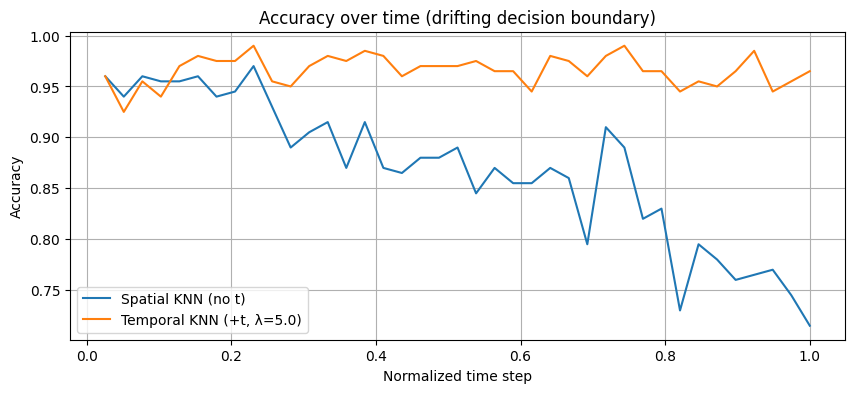

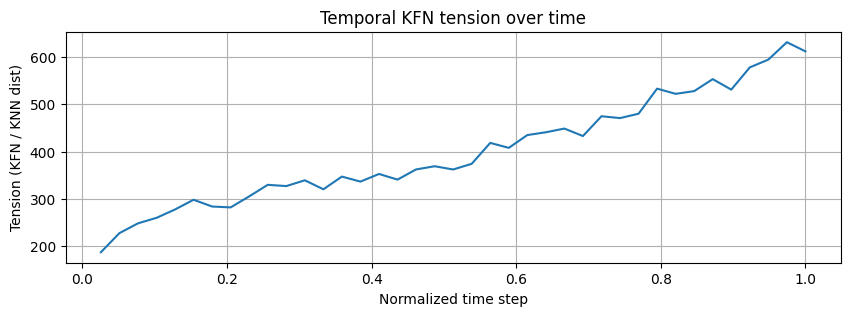

In [ ]:
# @title Temporal KNN + KFN experiment (single cell)
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate drifting dataset
# -----------------------------
np.random.seed(42)

T = 40          # number of time steps
N_step = 200    # samples per time step
D = 2           # feature dim
theta0 = 0.0    # initial decision boundary angle
theta1 = np.pi/2  # final angle (90° rotation)

N = T * N_step

# Base features (stationary in space)
Z = np.random.randn(N, D)

# Time step index per sample (0..T-1)
step_idx = np.repeat(np.arange(T), N_step)
t = step_idx / (T - 1)   # normalize time to [0,1]

# Angle per sample
theta = theta0 + (theta1 - theta0) * t
w = np.stack([np.cos(theta), np.sin(theta)], axis=1)  # direction vector

# Labels: sign(w(t) · z)
logits = np.sum(Z * w, axis=1)
y = (logits > 0).astype(int)

X = Z  # Just treat Z as observed features

print(f"Total samples: {N}, classes: {np.bincount(y)}")

# -----------------------------
# 2. KNN helpers (spatial & temporal)
# -----------------------------
def knn_predict_spatial(X_train, y_train, X_test, k=5):
    """
    Pure spatial KNN (Euclidean), majority vote.
    """
    if X_train.shape[0] == 0:
        raise ValueError("No training data provided.")
    k_eff = min(k, X_train.shape[0])

    # pairwise squared distances
    diff = X_test[:, None, :] - X_train[None, :, :]
    dist2 = np.sum(diff ** 2, axis=2)

    # get indices of k nearest neighbors
    idx_knn = np.argpartition(dist2, k_eff - 1, axis=1)[:, :k_eff]
    y_neighbors = y_train[idx_knn]

    # majority vote
    preds = (np.mean(y_neighbors, axis=1) >= 0.5).astype(int)
    return preds


def knn_predict_temporal(X_train, y_train, t_train, X_test, t_test, k=5, lambda_time=5.0):
    """
    Temporal KNN:
      - distance^2 = ||x_i - x_q||^2 + lambda_time^2 * (Δt)^2
      - only uses training points with t_train <= t_test (causal)
    Also returns a KFN-based "tension" score per test sample.
    """
    if X_train.shape[0] == 0:
        raise ValueError("No training data provided.")
    k_eff = min(k, X_train.shape[0])

    # spatial part
    diff = X_test[:, None, :] - X_train[None, :, :]
    dist2 = np.sum(diff ** 2, axis=2)

    # temporal part
    dt = t_test[:, None] - t_train[None, :]  # query - train
    # mask out future points: t_train > t_test => invalid
    mask_future = dt < 0.0
    dt_sq = dt ** 2

    dist2_aug = dist2 + (lambda_time ** 2) * dt_sq
    dist2_aug[mask_future] = np.inf  # disallow future neighbors

    # If some rows have fewer than k finite distances, reduce k_eff per row
    preds = np.zeros(X_test.shape[0], dtype=int)
    tension = np.full(X_test.shape[0], np.nan)

    for i in range(X_test.shape[0]):
        row = dist2_aug[i]
        finite_mask = np.isfinite(row)
        if not np.any(finite_mask):
            # No valid past neighbors at all (can happen very early)
            continue
        d_i = row[finite_mask]
        y_i = y_train[finite_mask]

        k_i = min(k, d_i.shape[0])

        # KNN (nearest)
        nn_idx_local = np.argpartition(d_i, k_i - 1)[:k_i]
        y_neighbors = y_i[nn_idx_local]
        preds[i] = (np.mean(y_neighbors) >= 0.5).astype(int)

        # KFN (furthest) for tension
        fn_idx_local = np.argpartition(-d_i, k_i - 1)[:k_i]
        near_mean = float(np.mean(d_i[nn_idx_local]))
        far_mean = float(np.mean(d_i[fn_idx_local]))
        if near_mean > 0:
            tension[i] = far_mean / near_mean

    return preds, tension


# -----------------------------
# 3. Streaming evaluation over time
# -----------------------------
K = 5
lambda_time = 5.0  # try changing this (e.g., 0.0, 1.0, 10.0)

acc_spatial = []
acc_temporal = []
tension_over_time = []
time_points = []

for s in range(1, T):  # start at 1 so we always have some past
    train_mask = step_idx < s
    test_mask = step_idx == s

    X_train, y_train, t_train = X[train_mask], y[train_mask], t[train_mask]
    X_test, y_test, t_test = X[test_mask], y[test_mask], t[test_mask]

    if X_train.shape[0] == 0 or X_test.shape[0] == 0:
        continue

    # Spatial KNN
    y_pred_spatial = knn_predict_spatial(X_train, y_train, X_test, k=K)
    acc_s = np.mean(y_pred_spatial == y_test)

    # Temporal KNN (+t) and tension
    y_pred_temp, tension = knn_predict_temporal(
        X_train, y_train, t_train,
        X_test, t_test,
        k=K, lambda_time=lambda_time
    )
    # Some early points might be unpredicted if no past neighbors (tension NaN)
    valid_mask = ~np.isnan(tension)
    if np.any(valid_mask):
        acc_t = np.mean(y_pred_temp[valid_mask] == y_test[valid_mask])
        tension_mean = np.nanmean(tension)
    else:
        acc_t = np.nan
        tension_mean = np.nan

    acc_spatial.append(acc_s)
    acc_temporal.append(acc_t)
    tension_over_time.append(tension_mean)
    time_points.append(s / (T - 1))

print("Overall (mean over time steps)")
print(f"  Spatial KNN accuracy:   {np.nanmean(acc_spatial):.3f}")
print(f"  Temporal KNN(+t) acc.:  {np.nanmean(acc_temporal):.3f}")
print(f"  Mean tension:           {np.nanmean(tension_over_time):.3f}")

# -----------------------------
# 4. Plots
# -----------------------------
time_points = np.array(time_points)
acc_spatial = np.array(acc_spatial)
acc_temporal = np.array(acc_temporal)
tension_over_time = np.array(tension_over_time)

plt.figure(figsize=(10, 4))
plt.plot(time_points, acc_spatial, label="Spatial KNN (no t)")
plt.plot(time_points, acc_temporal, label=f"Temporal KNN (+t, λ={lambda_time})")
plt.xlabel("Normalized time step")
plt.ylabel("Accuracy")
plt.title("Accuracy over time (drifting decision boundary)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(time_points, tension_over_time)
plt.xlabel("Normalized time step")
plt.ylabel("Tension (KFN / KNN dist)")
plt.title("Temporal KFN tension over time")
plt.grid(True)
plt.show()

/tmp/ipython-input-2205224174.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", interval="1d", group_by="column")
[*********************100%***********************]  1 of 1 completed


Raw columns from yfinance: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2020-11-27  113.494797  114.370905  113.134624  113.475331   46691300
2020-11-30  115.889503  117.758530  113.708965  113.864721  169410200
2020-12-01  119.462067  120.192156  116.824012  117.797464  127728200
2020-12-02  119.812515  120.094817  117.680652  118.780651   89004200
2020-12-03  119.676231  120.493928  118.965608  120.240828   78967600
Flattened columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Total usable samples: 1254
Class balance: [589 665]
==== Streaming results on AAPL (direction prediction) ====
Samp

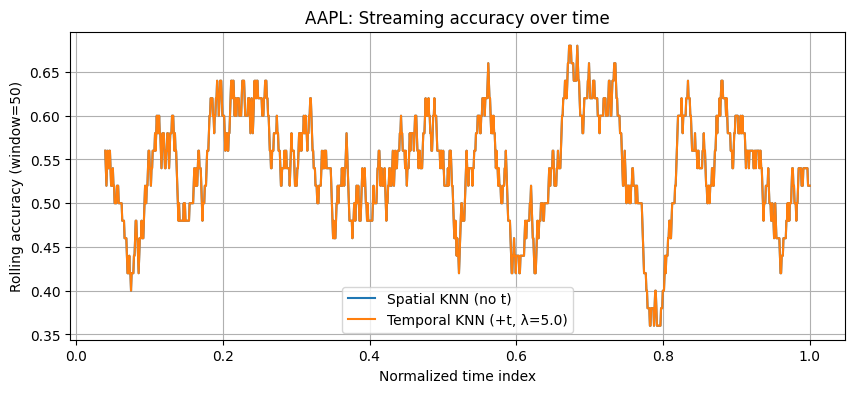

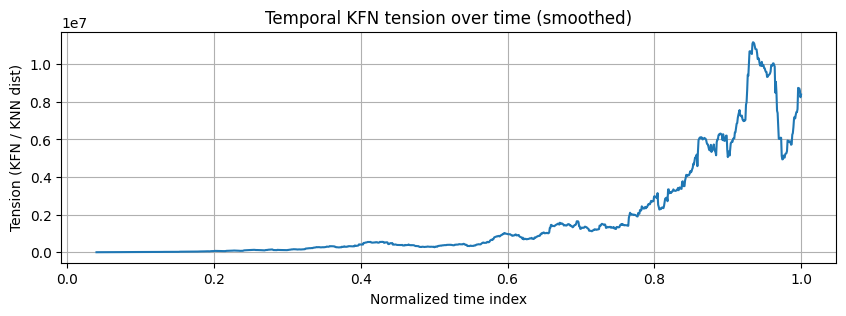

In [ ]:
# @title Temporal KNN + KFN on real stock data (AAPL via yfinance) — ROBUST VERSION

!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# -----------------------------
# 1. Download real time-series data (AAPL)
# -----------------------------
ticker = "AAPL"

# Force grouping by column so we get Open/High/Low/Close/Volume, not per-ticker columns
df = yf.download(ticker, period="5y", interval="1d", group_by="column")
df = df.dropna()

print("Raw columns from yfinance:", df.columns)
print(df.head())

# If columns are still MultiIndex, flatten them by taking the first level (Open, High, etc.)
if isinstance(df.columns, pd.MultiIndex):
    # Typically level 0 = ["Open","High","Low","Close","Adj Close","Volume"]
    df.columns = df.columns.get_level_values(0)
    print("Flattened columns:", df.columns)

# Sanity check: make sure we now have these columns
needed = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise RuntimeError(f"Expected OHLCV columns missing: {missing}. Got: {df.columns}")

# -----------------------------
# 2. Build supervised dataset
#    - Features: OHLCV
#    - Label: 1 if next close > current close, else 0
#    - Time: Julian date as float
# -----------------------------
# Time coordinate
t_all = df.index.to_julian_date().astype(float).values  # shape (N,)

# Raw features
X_raw = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=float)

# Label: next-day direction (ensure 1D)
close = df["Close"].to_numpy(dtype=float)              # shape (N,)
y_all = (np.roll(close, -1) > close).astype(int)       # shape (N,)

# Drop last sample (no next-day label)
X_all = X_raw[:-1]
y_all = y_all[:-1]
t_all = t_all[:-1]

N_total = len(X_all)
print(f"Total usable samples: {N_total}")
print("Class balance:", np.bincount(y_all))

# Optionally limit for speed
N_use = N_total  # or e.g. 1500 for faster run
X = X_all[:N_use]
y = y_all[:N_use]
t = t_all[:N_use]
N = len(X)

# -----------------------------
# 3. KNN helpers (spatial & temporal)
# -----------------------------
def knn_predict_spatial(X_train, y_train, X_test, k=5):
    """
    Pure spatial KNN (Euclidean), majority vote.
    """
    if X_train.shape[0] == 0:
        return np.zeros(len(X_test), dtype=int)
    k_eff = min(k, X_train.shape[0])

    diff = X_test[:, None, :] - X_train[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    idx = np.argpartition(dist2, k_eff - 1, axis=1)[:, :k_eff]
    y_neighbors = y_train[idx]
    return (np.mean(y_neighbors, axis=1) >= 0.5).astype(int)


def knn_predict_temporal(X_train, y_train, t_train,
                         X_test, t_test, k=5, lambda_time=5.0):
    """
    Temporal KNN:
      d^2 = ||x_i - x_q||^2 + lambda_time^2 * (Δt)^2
    with causality: only t_train <= t_test.
    Returns:
      preds: temporal KNN predictions
      tension: KFN-based tension (far/near mean distance) per test sample
    """
    if X_train.shape[0] == 0:
        return np.zeros(len(X_test), dtype=int), np.full(len(X_test), np.nan)
    k_eff = min(k, X_train.shape[0])

    diff = X_test[:, None, :] - X_train[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    dt = t_test[:, None] - t_train[None, :]
    future_mask = dt < 0
    dt2 = dt**2

    dist2_aug = dist2 + (lambda_time**2) * dt2
    dist2_aug[future_mask] = np.inf

    preds = []
    tensions = []

    for i in range(dist2_aug.shape[0]):
        row = dist2_aug[i]
        mask = np.isfinite(row)
        if not np.any(mask):
            preds.append(0)
            tensions.append(np.nan)
            continue

        d_valid = row[mask]
        y_valid = y_train[mask]
        k_i = min(k, len(d_valid))

        # K nearest
        knn_idx = np.argpartition(d_valid, k_i - 1)[:k_i]
        y_neighbors = y_valid[knn_idx]
        preds.append(int(np.mean(y_neighbors) >= 0.5))

        # K furthest for tension
        kfn_idx = np.argpartition(-d_valid, k_i - 1)[:k_i]
        near_mean = float(np.mean(d_valid[knn_idx]))
        far_mean = float(np.mean(d_valid[kfn_idx]))
        tensions.append(far_mean / near_mean if near_mean > 0 else np.nan)

    return np.array(preds), np.array(tensions)


# -----------------------------
# 4. Streaming evaluation (online)
# -----------------------------
K = 5
lambda_time = 5.0  # try 0.0, 1.0, 3.0, 10.0 too

acc_spatial = []
acc_temporal = []
tension_list = []
time_points = []

for s in range(1, N):
    X_train = X[:s]
    y_train = y[:s]
    t_train = t[:s]

    X_test = X[s:s+1]
    y_test = y[s:s+1]
    t_test = t[s:s+1]

    # Spatial KNN
    pred_s = knn_predict_spatial(X_train, y_train, X_test, k=K)[0]
    acc_spatial.append(int(pred_s == y_test[0]))

    # Temporal KNN (+t)
    pred_t, tens = knn_predict_temporal(X_train, y_train, t_train,
                                        X_test, t_test,
                                        k=K, lambda_time=lambda_time)
    acc_temporal.append(int(pred_t[0] == y_test[0]))
    tension_list.append(tens[0])

    time_points.append(s / (N - 1))

acc_spatial = np.array(acc_spatial, float)
acc_temporal = np.array(acc_temporal, float)
tension_arr = np.array(tension_list, float)
time_points = np.array(time_points)

# -----------------------------
# 5. Summary stats
# -----------------------------
print("==== Streaming results on AAPL (direction prediction) ====")
print(f"Samples used (excluding first): {len(acc_spatial)}")
print(f"Spatial KNN accuracy:   {acc_spatial.mean():.3f}")
print(f"Temporal KNN(+t) acc.:  {acc_temporal.mean():.3f}")
print(f"Mean tension:           {np.nanmean(tension_arr):.3f}")

# -----------------------------
# 6. Plots
# -----------------------------
window = 50  # rolling window size for smoothing

def rolling_mean(x, w):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

tp = time_points[window-1:]
acc_spatial_s = rolling_mean(acc_spatial, window)
acc_temporal_s = rolling_mean(acc_temporal, window)
tension_s = rolling_mean(
    np.nan_to_num(tension_arr, nan=np.nanmean(tension_arr)),
    window
)

plt.figure(figsize=(10, 4))
plt.plot(tp, acc_spatial_s, label="Spatial KNN (no t)")
plt.plot(tp, acc_temporal_s, label=f"Temporal KNN (+t, λ={lambda_time})")
plt.xlabel("Normalized time index")
plt.ylabel(f"Rolling accuracy (window={window})")
plt.title(f"{ticker}: Streaming accuracy over time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(tp, tension_s)
plt.xlabel("Normalized time index")
plt.ylabel("Tension (KFN / KNN dist)")
plt.title("Temporal KFN tension over time (smoothed)")
plt.grid()
plt.show()

/tmp/ipython-input-1871041035.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", interval="1d", group_by="column")
[*********************100%***********************]  1 of 1 completed


Raw columns: MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])
Flattened columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price            Close        High         Low        Open     Volume
Date                                                                 
2020-11-27  113.494789  114.370898  113.134617  113.475323   46691300
2020-11-30  115.889503  117.758530  113.708965  113.864721  169410200
2020-12-01  119.462074  120.192164  116.824019  117.797472  127728200
2020-12-02  119.812531  120.094833  117.680667  118.780666   89004200
2020-12-03  119.676216  120.493912  118.965593  120.240813   78967600

Total usable samples (with 5-day vol label): 1251
Vol median: 0.01376286164579719
Class balance [low, high]: [625 626]

==== Streaming results on REAL AAPL (5-day vol regime) series ====
Samples use

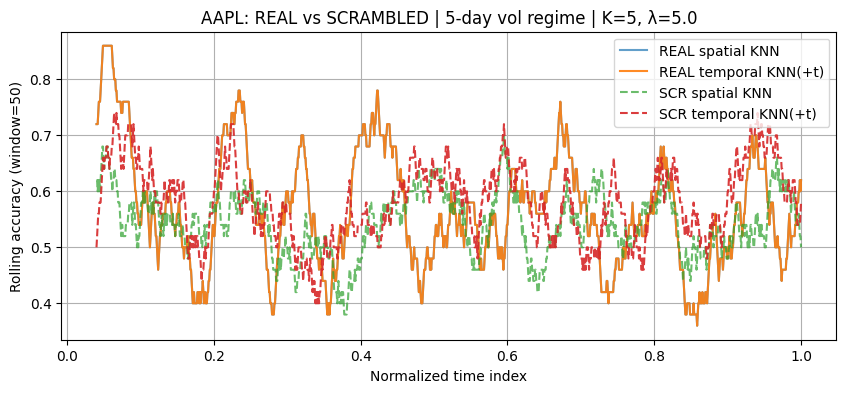

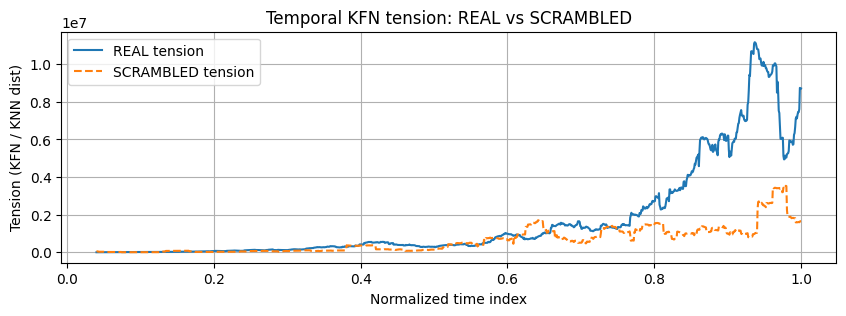

In [ ]:
# @title Temporal Geometry Test: Real vs Scrambled (AAPL, 5-day volatility regime) — FIXED

!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# -----------------------------
# 1. Download AAPL OHLCV, flatten columns
# -----------------------------
ticker = "AAPL"
df = yf.download(ticker, period="5y", interval="1d", group_by="column")
df = df.dropna()

print("Raw columns:", df.columns)

# Flatten MultiIndex if needed: ('Close','AAPL') -> 'Close', etc.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
    print("Flattened columns:", df.columns)

needed = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing expected OHLCV columns: {missing}")

print(df.head())

# -----------------------------
# 2. Build 5-day realized volatility regime label
# -----------------------------
H = 5  # horizon for realized volatility

close = df["Close"].to_numpy(dtype=float)           # shape (M,)
dates = df.index
# NOTE: force to numpy array here to avoid pandas multi-d indexing issues
t_all_full = dates.to_julian_date().to_numpy(dtype=float)  # shape (M,)

X_raw = df[["Open", "High", "Low", "Close", "Volume"]].to_numpy(dtype=float)

M = len(close)
# daily log returns: r_j = log(C_{j+1}/C_j), j=0..M-2
logret = np.diff(np.log(close))                    # shape (M-1,)

# realized volatility for each base day i using returns from i..i+H-1
# requires i+H <= M-1 -> i <= M-1-H
L = M - H
vol = np.empty(L, dtype=float)
for i in range(L):
    window = logret[i:i+H]  # length H
    vol[i] = np.sqrt(np.mean(window**2))

# Features and time for first L days
X_all = X_raw[:L]
t_all = t_all_full[:L]              # now definitely a NumPy array
dates_all = dates[:L]

# Binarize vol into low/high regime by median
median_vol = np.median(vol)
y_all = (vol >= median_vol).astype(int)  # 1 = high vol, 0 = low vol

print(f"\nTotal usable samples (with 5-day vol label): {L}")
print("Vol median:", median_vol)
print("Class balance [low, high]:", np.bincount(y_all))

# -----------------------------
# 3. KNN helpers (spatial & temporal)
# -----------------------------
def knn_predict_spatial(X_train, y_train, X_test, k=5):
    """
    Pure spatial KNN (Euclidean), majority vote.
    """
    if X_train.shape[0] == 0:
        return np.zeros(len(X_test), dtype=int)
    k_eff = min(k, X_train.shape[0])

    diff = X_test[:, None, :] - X_train[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    idx = np.argpartition(dist2, k_eff - 1, axis=1)[:, :k_eff]
    y_neighbors = y_train[idx]
    return (np.mean(y_neighbors, axis=1) >= 0.5).astype(int)


def knn_predict_temporal(X_train, y_train, t_train,
                         X_test, t_test, k=5, lambda_time=5.0):
    """
    Temporal KNN:
      d^2 = ||x_i - x_q||^2 + lambda_time^2 * (Δt)^2
    with causality: only t_train <= t_test.
    Returns:
      preds: temporal KNN predictions
      tension: KFN-based tension (far/near mean distance) per test sample
    """
    if X_train.shape[0] == 0:
        return np.zeros(len(X_test), dtype=int), np.full(len(X_test), np.nan)
    k_eff = min(k, X_train.shape[0])

    diff = X_test[:, None, :] - X_train[None, :, :]
    dist2 = np.sum(diff**2, axis=2)

    dt = t_test[:, None] - t_train[None, :]
    future_mask = dt < 0
    dt2 = dt**2

    dist2_aug = dist2 + (lambda_time**2) * dt2
    dist2_aug[future_mask] = np.inf

    preds = []
    tensions = []

    for i in range(dist2_aug.shape[0]):
        row = dist2_aug[i]
        mask = np.isfinite(row)
        if not np.any(mask):
            preds.append(0)
            tensions.append(np.nan)
            continue

        d_valid = row[mask]
        y_valid = y_train[mask]
        k_i = min(k, len(d_valid))

        # K nearest
        knn_idx = np.argpartition(d_valid, k_i - 1)[:k_i]
        y_neighbors = y_valid[knn_idx]
        preds.append(int(np.mean(y_neighbors) >= 0.5))

        # K furthest for tension
        kfn_idx = np.argpartition(-d_valid, k_i - 1)[:k_i]
        near_mean = float(np.mean(d_valid[knn_idx]))
        far_mean = float(np.mean(d_valid[kfn_idx]))
        tensions.append(far_mean / near_mean if near_mean > 0 else np.nan)

    return np.array(preds), np.array(tensions)


# -----------------------------
# 4. Streaming experiment runner
# -----------------------------
def run_streaming_experiment(X, y, t, K=5, lambda_time=5.0, name="real"):
    """
    Online evaluation: at step s, train on [0..s-1], predict s.
    Returns dict with accuracies and tension arrays.
    """
    N = len(X)
    acc_spatial = []
    acc_temporal = []
    tension_list = []
    time_points = []

    for s in range(1, N):
        X_train = X[:s]
        y_train = y[:s]
        t_train = t[:s]

        X_test = X[s:s+1]
        y_test = y[s:s+1]
        t_test = t[s:s+1]

        # Spatial KNN
        pred_s = knn_predict_spatial(X_train, y_train, X_test, k=K)[0]
        acc_spatial.append(int(pred_s == y_test[0]))

        # Temporal KNN(+t)
        pred_t, tens = knn_predict_temporal(
            X_train, y_train, t_train,
            X_test, t_test,
            k=K, lambda_time=lambda_time
        )
        acc_temporal.append(int(pred_t[0] == y_test[0]))
        tension_list.append(tens[0])

        time_points.append(s / (N - 1))

    acc_spatial = np.array(acc_spatial, float)
    acc_temporal = np.array(acc_temporal, float)
    tension_arr = np.array(tension_list, float)
    time_points = np.array(time_points)

    print(f"\n==== Streaming results on {name} series ====")
    print(f"Samples used (excluding first): {len(acc_spatial)}")
    print(f"Spatial KNN accuracy:   {acc_spatial.mean():.3f}")
    print(f"Temporal KNN(+t) acc.:  {acc_temporal.mean():.3f}")
    print(f"Mean tension:           {np.nanmean(tension_arr):.3f}")

    return {
        "acc_spatial": acc_spatial,
        "acc_temporal": acc_temporal,
        "tension": tension_arr,
        "time_points": time_points,
    }


def rolling_mean(x, w):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w)/w, mode="valid")


# -----------------------------
# 5. Run on REAL series
# -----------------------------
K = 5
lambda_time = 5.0

results_real = run_streaming_experiment(
    X_all, y_all, t_all,
    K=K, lambda_time=lambda_time,
    name="REAL AAPL (5-day vol regime)"
)

# -----------------------------
# 6. Run on SCRAMBLED series (destroy temporal order)
# -----------------------------
np.random.seed(0)
perm = np.random.permutation(len(X_all))
X_scr = X_all[perm]
y_scr = y_all[perm]
t_scr = t_all[perm]  # time now misaligned with original evolution

results_scr = run_streaming_experiment(
    X_scr, y_scr, t_scr,
    K=K, lambda_time=lambda_time,
    name="SCRAMBLED AAPL (time-shuffled)"
)

# -----------------------------
# 7. Plot comparison: REAL vs SCRAMBLED
# -----------------------------
window = 50

def plot_results(real, scr, label, title):
    tp_r = real["time_points"][window-1:]
    tp_s = scr["time_points"][window-1:]

    r_sp = rolling_mean(real["acc_spatial"], window)
    r_tp = rolling_mean(real["acc_temporal"], window)
    s_sp = rolling_mean(scr["acc_spatial"], window)
    s_tp = rolling_mean(scr["acc_temporal"], window)

    plt.figure(figsize=(10,4))
    plt.plot(tp_r, r_sp, label="REAL spatial KNN", alpha=0.7)
    plt.plot(tp_r, r_tp, label="REAL temporal KNN(+t)", alpha=0.9)
    plt.plot(tp_s, s_sp, "--", label="SCR spatial KNN", alpha=0.7)
    plt.plot(tp_s, s_tp, "--", label="SCR temporal KNN(+t)", alpha=0.9)
    plt.xlabel("Normalized time index")
    plt.ylabel(f"Rolling {label} (window={window})")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Accuracy comparison
plot_results(
    results_real, results_scr,
    label="accuracy",
    title=f"{ticker}: REAL vs SCRAMBLED | 5-day vol regime | K={K}, λ={lambda_time}"
)

# Tension comparison
t_r = rolling_mean(
    np.nan_to_num(results_real["tension"], nan=np.nanmean(results_real["tension"])),
    window
)
t_s = rolling_mean(
    np.nan_to_num(results_scr["tension"], nan=np.nanmean(results_scr["tension"])),
    window
)
tp_r = results_real["time_points"][window-1:]
tp_s = results_scr["time_points"][window-1:]

plt.figure(figsize=(10,3))
plt.plot(tp_r, t_r, label="REAL tension")
plt.plot(tp_s, t_s, "--", label="SCRAMBLED tension")
plt.xlabel("Normalized time index")
plt.ylabel("Tension (KFN / KNN dist)")
plt.title("Temporal KFN tension: REAL vs SCRAMBLED")
plt.legend()
plt.grid(True)
plt.show()

/tmp/ipython-input-2960064321.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", interval="1d", group_by="column")
[*********************100%***********************]  1 of 1 completed


Columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price            Close        High         Low        Open     Volume
Date                                                                 
2020-11-27  113.494789  114.370898  113.134617  113.475323   46691300
2020-11-30  115.889496  117.758522  113.708957  113.864713  169410200
2020-12-01  119.462067  120.192156  116.824012  117.797464  127728200
2020-12-02  119.812508  120.094810  117.680645  118.780643   89004200
2020-12-03  119.676224  120.493920  118.965600  120.240820   78967600
Total days: 1256

Computing REAL tension series...
Computed tension for 200/1256 days...
Computed tension for 400/1256 days...
Computed tension for 600/1256 days...
Computed tension for 800/1256 days...
Computed tension for 1000/1256 days...
Computed tension for 1200/1256 days...
REAL tension stats: min= 1.0 max= 79089278.84278835 mean= 1844313.200435436

Computing SCRAMBLED tension series (time-shuffled)...
Computed 

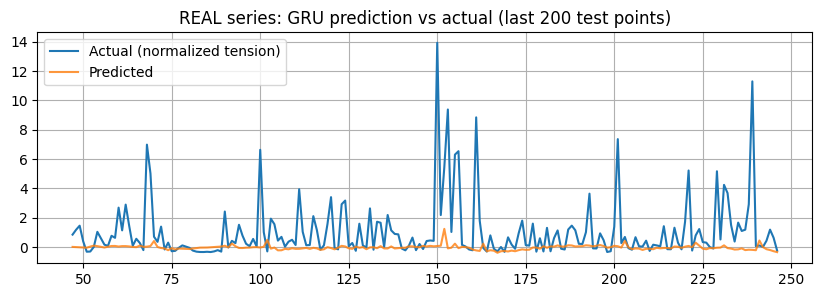

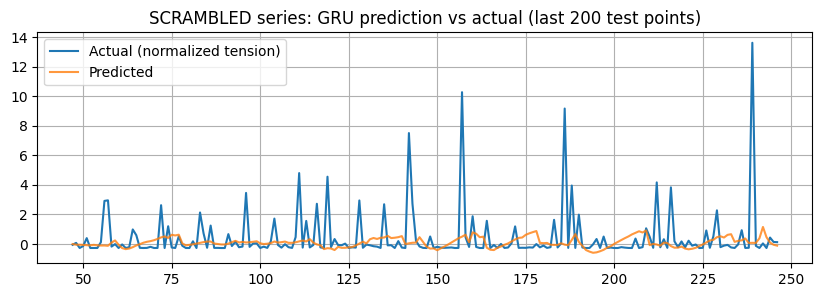

In [ ]:
# @title Temporal Geometry Forecasting: Predicting Tension Dynamics (REAL vs SCRAMBLED)

!pip install yfinance -q tensorflow -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers, models

np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# 1. Download AAPL OHLCV and prepare features
# -----------------------------
ticker = "AAPL"
df = yf.download(ticker, period="5y", interval="1d", group_by="column")
df = df.dropna()

# Flatten MultiIndex if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

needed = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing OHLCV columns: {missing}")

print("Columns:", df.columns)
print(df.head())

# Convert to numpy
X_full = df[needed].to_numpy(dtype=float)
dates = df.index
t_full = dates.to_julian_date().to_numpy(dtype=float)  # 1D np array

N = len(X_full)
print("Total days:", N)

# -----------------------------
# 2. KNN+KFN+t helper: single-step tension
# -----------------------------
def knn_kfn_tension_one(X_train, t_train, x_q, t_q, k=5, lambda_time=5.0):
    """
    Compute tension for a single query point:
      - distance^2 = ||x_i - x_q||^2 + lambda_time^2 * (Δt)^2
      - only t_train <= t_q allowed (causal)
      - tension = mean(KFN distances) / mean(KNN distances)
    """
    if X_train.shape[0] == 0:
        return np.nan

    # spatial distances
    diff = X_train - x_q[None, :]
    dist2 = np.sum(diff**2, axis=1)

    # temporal distances
    dt = t_q - t_train
    mask_future = dt < 0
    dt2 = dt**2

    dist2_aug = dist2 + (lambda_time**2) * dt2
    dist2_aug[mask_future] = np.inf

    finite_mask = np.isfinite(dist2_aug)
    if not np.any(finite_mask):
        return np.nan

    d = dist2_aug[finite_mask]
    k_eff = min(k, d.shape[0])

    # nearest
    knn_idx = np.argpartition(d, k_eff-1)[:k_eff]
    near_mean = float(np.mean(d[knn_idx]))

    # furthest
    kfn_idx = np.argpartition(-d, k_eff-1)[:k_eff]
    far_mean = float(np.mean(d[kfn_idx]))

    if near_mean <= 0:
        return np.nan
    return far_mean / near_mean


def compute_tension_series(X, t, k=5, lambda_time=5.0):
    """
    Compute tension_t for t=1..N-1 (each day predicted from all prior days).
    Returns a 1D numpy array of length N (tension[0] = nan).
    """
    N = len(X)
    tension = np.full(N, np.nan, dtype=float)
    for i in range(1, N):
        X_train = X[:i]
        t_train = t[:i]
        x_q = X[i]
        t_q = t[i]
        tension[i] = knn_kfn_tension_one(X_train, t_train, x_q, t_q,
                                         k=k, lambda_time=lambda_time)
        if i % 200 == 0:
            print(f"Computed tension for {i}/{N} days...")
    return tension

# -----------------------------
# 3. Compute REAL tension series
# -----------------------------
K = 5
lambda_time = 5.0

print("\nComputing REAL tension series...")
tension_real = compute_tension_series(X_full, t_full, k=K, lambda_time=lambda_time)

# Drop initial NaNs (if any) by simple forward fill for convenience
mask_valid = np.isfinite(tension_real)
first_valid = np.argmax(mask_valid)
if first_valid > 0:
    tension_real[:first_valid] = tension_real[first_valid]

print("REAL tension stats:",
      "min=", np.nanmin(tension_real),
      "max=", np.nanmax(tension_real),
      "mean=", np.nanmean(tension_real))

# -----------------------------
# 4. Compute SCRAMBLED tension series
# -----------------------------
print("\nComputing SCRAMBLED tension series (time-shuffled)...")
perm = np.random.permutation(N)
X_scr = X_full[perm]
t_scr = t_full[perm]
tension_scr = compute_tension_series(X_scr, t_scr, k=K, lambda_time=lambda_time)

mask_valid_s = np.isfinite(tension_scr)
first_valid_s = np.argmax(mask_valid_s)
if first_valid_s > 0:
    tension_scr[:first_valid_s] = tension_scr[first_valid_s]

print("SCR tension stats:",
      "min=", np.nanmin(tension_scr),
      "max=", np.nanmax(tension_scr),
      "mean=", np.nanmean(tension_scr))

# -----------------------------
# 5. Build (history -> next tension) datasets
# -----------------------------
def build_sequence_dataset(tension, L=20):
    """
    tension: 1D array
    L: history length
    Returns X_seq (num_samples, L, 1), y_seq (num_samples,)
    """
    # Replace any remaining NaNs with global mean
    t_clean = tension.copy()
    nan_mask = ~np.isfinite(t_clean)
    if np.any(nan_mask):
        t_clean[nan_mask] = np.nanmean(t_clean)

    # Standardize
    mean = t_clean.mean()
    std = t_clean.std() + 1e-8
    t_norm = (t_clean - mean) / std

    seq_X = []
    seq_y = []
    for i in range(L, len(t_norm)-1):
        seq_X.append(t_norm[i-L:i])
        seq_y.append(t_norm[i+1])  # next-day tension (normalized)

    seq_X = np.array(seq_X, dtype=float)[..., None]  # (N,L,1)
    seq_y = np.array(seq_y, dtype=float)

    return seq_X, seq_y, mean, std

L = 20

X_real_seq, y_real_seq, mean_real, std_real = build_sequence_dataset(tension_real, L=L)
X_scr_seq, y_scr_seq, mean_scr, std_scr = build_sequence_dataset(tension_scr, L=L)

print("\nREAL seq shape:", X_real_seq.shape, "labels:", y_real_seq.shape)
print("SCR  seq shape:", X_scr_seq.shape, "labels:", y_scr_seq.shape)

# -----------------------------
# 6. Train/test split
# -----------------------------
def train_test_split(X, y, test_frac=0.2):
    N = len(X)
    split = int((1 - test_frac) * N)
    return (X[:split], y[:split], X[split:], y[split:])

Xr_tr, yr_tr, Xr_te, yr_te = train_test_split(X_real_seq, y_real_seq)
Xs_tr, ys_tr, Xs_te, ys_te = train_test_split(X_scr_seq, y_scr_seq)

# -----------------------------
# 7. GRU model factory
# -----------------------------
def make_gru_model(L):
    model = models.Sequential([
        layers.Input(shape=(L, 1)),
        layers.GRU(32, activation="tanh"),
        layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

# -----------------------------
# 8. Train GRU on REAL tension
# -----------------------------
print("\nTraining GRU on REAL tension...")
model_real = make_gru_model(L)
history_real = model_real.fit(
    Xr_tr, yr_tr,
    validation_data=(Xr_te, yr_te),
    epochs=25,
    batch_size=32,
    verbose=0
)
print("Final REAL val loss (MSE):", history_real.history["val_loss"][-1])

# -----------------------------
# 9. Train GRU on SCRAMBLED tension
# -----------------------------
print("\nTraining GRU on SCRAMBLED tension...")
model_scr = make_gru_model(L)
history_scr = model_scr.fit(
    Xs_tr, ys_tr,
    validation_data=(Xs_te, ys_te),
    epochs=25,
    batch_size=32,
    verbose=0
)
print("Final SCR val loss (MSE):", history_scr.history["val_loss"][-1])

# -----------------------------
# 10. Evaluate vs naive persistence baseline
# -----------------------------
def eval_model(model, X_te, y_te):
    y_pred = model.predict(X_te, verbose=0).squeeze()
    mse = np.mean((y_pred - y_te)**2)
    # R^2 vs 0 baseline on normalized series
    var = np.var(y_te)
    r2 = 1 - mse / (var + 1e-8)
    return mse, r2, y_pred

def eval_persistence(y_full, L):
    """
    Persistence baseline: predict next tension = last tension in window.
    On normalized data this is just y_pred = X[:, -1].
    """
    # y_full is already normalized; build same test-label alignment as above:
    # For i in [L..len-2], label = y[i+1], baseline = y[i]
    y_norm = y_full
    labels = []
    preds = []
    for i in range(L, len(y_norm)-1):
        preds.append(y_norm[i])
        labels.append(y_norm[i+1])
    labels = np.array(labels)
    preds = np.array(preds)
    mse = np.mean((preds - labels)**2)
    var = np.var(labels)
    r2 = 1 - mse / (var + 1e-8)
    return mse, r2

# Evaluate GRU (using test splits)
mse_real, r2_real, y_pred_real = eval_model(model_real, Xr_te, yr_te)
mse_scr,  r2_scr,  y_pred_scr  = eval_model(model_scr,  Xs_te, ys_te)

# Persistence baselines on normalized sequences (train+test combined)
# Note: y_real_seq and y_scr_seq are entire normalized series.
mse_pers_real, r2_pers_real = eval_persistence(y_real_seq, L)
mse_pers_scr,  r2_pers_scr  = eval_persistence(y_scr_seq,  L)

print("\n=== REAL tension forecasting ===")
print("GRU  MSE:", mse_real, "R^2:", r2_real)
print("Pers MSE:", mse_pers_real, "R^2:", r2_pers_real)

print("\n=== SCRAMBLED tension forecasting ===")
print("GRU  MSE:", mse_scr, "R^2:", r2_scr)
print("Pers MSE:", mse_pers_scr, "R^2:", r2_pers_scr)

# -----------------------------
# 11. Plot predicted vs actual on last 200 test points
# -----------------------------
def plot_predictions(y_te, y_pred, title):
    n = len(y_te)
    k = min(200, n)
    xs = np.arange(n-k, n)
    plt.figure(figsize=(10,3))
    plt.plot(xs, y_te[-k:], label="Actual (normalized tension)")
    plt.plot(xs, y_pred[-k:], label="Predicted", alpha=0.8)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(yr_te, y_pred_real,
                 "REAL series: GRU prediction vs actual (last 200 test points)")
plot_predictions(ys_te, y_pred_scr,
                 "SCRAMBLED series: GRU prediction vs actual (last 200 test points)")

/tmp/ipython-input-4716265.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", interval="1d", group_by="column")
[*********************100%***********************]  1 of 1 completed


Columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price            Close        High         Low        Open     Volume
Date                                                                 
2020-11-27  113.494797  114.370905  113.134624  113.475331   46691300
2020-11-30  115.889519  117.758546  113.708980  113.864736  169410200
2020-12-01  119.462074  120.192164  116.824019  117.797472  127728200
2020-12-02  119.812508  120.094810  117.680645  118.780643   89004200
2020-12-03  119.676231  120.493928  118.965608  120.240828   78967600
Total days: 1256

Computing REAL tension...
Tension computed for 200/1256 days...
Tension computed for 400/1256 days...
Tension computed for 600/1256 days...
Tension computed for 800/1256 days...
Tension computed for 1000/1256 days...
Tension computed for 1200/1256 days...
REAL tension stats: min= 1.0 max= 79089278.84268868 mean= 1844313.2004352086

Computing SCRAMBLED tension...
Tension computed for 200/1256 days...


Final SCR val accuracy: 0.40890687704086304


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


=== REAL regime forecasting ===
GRU accuracy:        0.8987854251012146
Persistence accuracy 0.8340080971659919

=== SCRAMBLED regime forecasting ===
GRU accuracy:        0.4089068825910931
Persistence accuracy 0.32793522267206476

REAL GRU confusion matrix:
[[  0   0  21]
 [  0   0   4]
 [  0   0 222]]

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        21
           1      0.000     0.000     0.000         4
           2      0.899     1.000     0.947       222

    accuracy                          0.899       247
   macro avg      0.300     0.333     0.316       247
weighted avg      0.808     0.899     0.851       247


SCR GRU confusion matrix:
[[84  0 12]
 [31  0  8]
 [95  0 17]]

              precision    recall  f1-score   support

           0      0.400     0.875     0.549        96
           1      0.000     0.000     0.000        39
           2      0.459     0.152     0.228       112

    accuracy                 

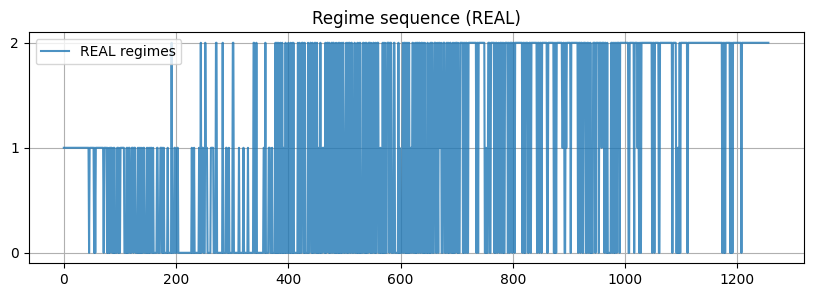

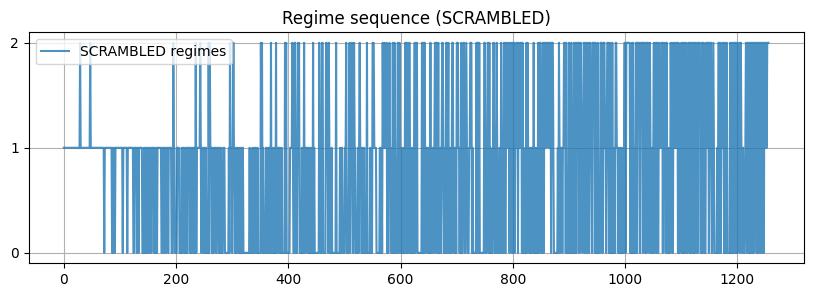

In [ ]:
# @title Temporal Regime Prediction: REAL vs SCRAMBLED (AAPL tension)
!pip install -q yfinance tensorflow scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# 1. Download AAPL OHLCV
# -----------------------------
ticker = "AAPL"
df = yf.download(ticker, period="5y", interval="1d", group_by="column")
df = df.dropna()

# Flatten MultiIndex if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

needed = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing OHLCV columns: {missing}")

print("Columns:", df.columns)
print(df.head())

X_full = df[needed].to_numpy(dtype=float)
dates = df.index
t_full = dates.to_julian_date().to_numpy(dtype=float)
N = len(X_full)
print("Total days:", N)

# -----------------------------
# 2. KNN+KFN+t tension helpers
# -----------------------------
def knn_kfn_tension_one(X_train, t_train, x_q, t_q, k=5, lambda_time=5.0):
    if X_train.shape[0] == 0:
        return np.nan
    diff = X_train - x_q[None, :]
    dist2 = np.sum(diff**2, axis=1)
    dt = t_q - t_train
    mask_future = dt < 0
    dt2 = dt**2
    dist2_aug = dist2 + (lambda_time**2)*dt2
    dist2_aug[mask_future] = np.inf

    finite_mask = np.isfinite(dist2_aug)
    if not np.any(finite_mask):
        return np.nan
    d = dist2_aug[finite_mask]
    k_eff = min(k, d.shape[0])

    knn_idx = np.argpartition(d, k_eff-1)[:k_eff]
    near_mean = float(np.mean(d[knn_idx]))
    kfn_idx = np.argpartition(-d, k_eff-1)[:k_eff]
    far_mean = float(np.mean(d[kfn_idx]))
    if near_mean <= 0:
        return np.nan
    return far_mean / near_mean

def compute_tension_series(X, t, k=5, lambda_time=5.0):
    N = len(X)
    tension = np.full(N, np.nan, dtype=float)
    for i in range(1, N):
        tension[i] = knn_kfn_tension_one(
            X[:i], t[:i], X[i], t[i],
            k=k, lambda_time=lambda_time
        )
        if i % 200 == 0:
            print(f"Tension computed for {i}/{N} days...")
    # simple forward fill for initial NaNs
    first_valid = np.argmax(np.isfinite(tension))
    if first_valid > 0:
        tension[:first_valid] = tension[first_valid]
    return tension

K = 5
lambda_time = 5.0

print("\nComputing REAL tension...")
tension_real = compute_tension_series(X_full, t_full, k=K, lambda_time=lambda_time)
print("REAL tension stats:",
      "min=", np.nanmin(tension_real),
      "max=", np.nanmax(tension_real),
      "mean=", np.nanmean(tension_real))

print("\nComputing SCRAMBLED tension...")
perm = np.random.permutation(N)
X_scr = X_full[perm]
t_scr = t_full[perm]
tension_scr = compute_tension_series(X_scr, t_scr, k=K, lambda_time=lambda_time)
print("SCR tension stats:",
      "min=", np.nanmin(tension_scr),
      "max=", np.nanmax(tension_scr),
      "mean=", np.nanmean(tension_scr))

# Replace remaining NaNs with mean
for arr in (tension_real, tension_scr):
    nan_mask = ~np.isfinite(arr)
    if np.any(nan_mask):
        arr[nan_mask] = np.nanmean(arr)

# -----------------------------
# 3. Define regimes via KMeans on REAL tension
# -----------------------------
# Use log-scale to compress extreme values
log_t_real = np.log1p(tension_real)
log_t_real = log_t_real.reshape(-1, 1)

n_regimes = 3
kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init=10)
kmeans.fit(log_t_real)
regime_real = kmeans.predict(log_t_real)

log_t_scr = np.log1p(tension_scr).reshape(-1, 1)
regime_scr = kmeans.predict(log_t_scr)  # use SAME clustering for comparability

print("\nRegime counts (REAL):", np.bincount(regime_real))
print("Regime counts (SCR):", np.bincount(regime_scr))

# -----------------------------
# 4. Build sequence datasets: past L tensions -> next regime
# -----------------------------
def build_regime_dataset(tension, regimes, L=20):
    t_clean = tension.copy()
    nan_mask = ~np.isfinite(t_clean)
    if np.any(nan_mask):
        t_clean[nan_mask] = np.nanmean(t_clean)

    mean = t_clean.mean()
    std = t_clean.std() + 1e-8
    t_norm = (t_clean - mean) / std

    X_seq = []
    y_reg = []
    prev_reg = []

    for i in range(L, len(t_norm)-1):
        # history window [i-L, ..., i-1]
        X_seq.append(t_norm[i-L:i])
        y_reg.append(regimes[i+1])   # next-day regime
        prev_reg.append(regimes[i])  # persistence baseline: last regime in window

    X_seq = np.array(X_seq, dtype=float)[..., None]  # (N_samples, L, 1)
    y_reg = np.array(y_reg, dtype=int)
    prev_reg = np.array(prev_reg, dtype=int)
    return X_seq, y_reg, prev_reg

L = 20
X_real_seq, y_real_reg, prev_real_reg = build_regime_dataset(tension_real, regime_real, L=L)
X_scr_seq,  y_scr_reg,  prev_scr_reg  = build_regime_dataset(tension_scr,  regime_scr,  L=L)

print("\nSeq shapes:")
print("REAL X:", X_real_seq.shape, "y:", y_real_reg.shape)
print("SCR  X:", X_scr_seq.shape,  "y:", y_scr_reg.shape)

# -----------------------------
# 5. Train/test split (time-respecting)
# -----------------------------
def split_seq(X, y, prev, test_frac=0.2):
    N = len(X)
    split = int((1 - test_frac) * N)
    return (X[:split], y[:split], prev[:split],
            X[split:], y[split:], prev[split:])

Xr_tr, yr_tr, prev_r_tr, Xr_te, yr_te, prev_r_te = split_seq(X_real_seq, y_real_reg, prev_real_reg)
Xs_tr, ys_tr, prev_s_tr, Xs_te, ys_te, prev_s_te = split_seq(X_scr_seq,  y_scr_reg,  prev_scr_reg)

# -----------------------------
# 6. GRU model factory
# -----------------------------
def make_gru_classifier(L, n_classes):
    model = models.Sequential([
        layers.Input(shape=(L, 1)),
        layers.GRU(32, activation="tanh"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# -----------------------------
# 7. Train GRU on REAL regimes
# -----------------------------
print("\nTraining GRU on REAL regimes...")
model_real = make_gru_classifier(L, n_regimes)
history_real = model_real.fit(
    Xr_tr, yr_tr,
    validation_data=(Xr_te, yr_te),
    epochs=30,
    batch_size=32,
    verbose=0
)
print("Final REAL val accuracy:", history_real.history["val_accuracy"][-1])

# -----------------------------
# 8. Train GRU on SCRAMBLED regimes
# -----------------------------
print("\nTraining GRU on SCRAMBLED regimes...")
model_scr = make_gru_classifier(L, n_regimes)
history_scr = model_scr.fit(
    Xs_tr, ys_tr,
    validation_data=(Xs_te, ys_te),
    epochs=30,
    batch_size=32,
    verbose=0
)
print("Final SCR val accuracy:", history_scr.history["val_accuracy"][-1])

# -----------------------------
# 9. Evaluate GRU vs persistence baseline
# -----------------------------
def eval_classifier(model, X_te, y_te):
    probs = model.predict(X_te, verbose=0)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_te).mean()
    return acc, y_pred

acc_real_gru, y_real_pred = eval_classifier(model_real, Xr_te, yr_te)
acc_scr_gru,  y_scr_pred  = eval_classifier(model_scr,  Xs_te, ys_te)

acc_real_pers = (prev_r_te == yr_te).mean()
acc_scr_pers  = (prev_s_te == ys_te).mean()

print("\n=== REAL regime forecasting ===")
print("GRU accuracy:       ", acc_real_gru)
print("Persistence accuracy", acc_real_pers)

print("\n=== SCRAMBLED regime forecasting ===")
print("GRU accuracy:       ", acc_scr_gru)
print("Persistence accuracy", acc_scr_pers)

# -----------------------------
# 10. Confusion matrices
# -----------------------------
def print_confusions(name, y_true, y_pred):
    print(f"\n{name} confusion matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\n" + classification_report(y_true, y_pred, digits=3))

print_confusions("REAL GRU", yr_te, y_real_pred)
print_confusions("SCR GRU", ys_te, y_scr_pred)

# -----------------------------
# 11. Optional: Plot regimes over time (REAL vs SCR)
# -----------------------------
plt.figure(figsize=(10,3))
plt.plot(regime_real, label="REAL regimes", alpha=0.8)
plt.title("Regime sequence (REAL)")
plt.yticks(range(n_regimes))
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,3))
plt.plot(regime_scr, label="SCRAMBLED regimes", alpha=0.8)
plt.title("Regime sequence (SCRAMBLED)")
plt.yticks(range(n_regimes))
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# @title Multi-step Regime Forecasting on AAPL (REAL vs SCRAMBLED)
!pip install -q yfinance tensorflow scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# 1. Download AAPL OHLCV
# -----------------------------
ticker = "AAPL"
df = yf.download(ticker, period="5y", interval="1d", group_by="column")
df = df.dropna()

# Flatten MultiIndex if needed
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

needed = ["Open", "High", "Low", "Close", "Volume"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise RuntimeError(f"Missing OHLCV columns: {missing}")

print("Columns:", df.columns)
print(df.head())

X_full = df[needed].to_numpy(dtype=float)
dates = df.index
t_full = dates.to_julian_date().to_numpy(dtype=float)
N = len(X_full)
print("Total days:", N)

# -----------------------------
# 2. KNN+KFN+t tension helpers
# -----------------------------
def knn_kfn_tension_one(X_train, t_train, x_q, t_q, k=5, lambda_time=5.0):
    if X_train.shape[0] == 0:
        return np.nan
    diff = X_train - x_q[None, :]
    dist2 = np.sum(diff**2, axis=1)
    dt = t_q - t_train
    mask_future = dt < 0
    dt2 = dt**2
    dist2_aug = dist2 + (lambda_time**2)*dt2
    dist2_aug[mask_future] = np.inf

    finite_mask = np.isfinite(dist2_aug)
    if not np.any(finite_mask):
        return np.nan
    d = dist2_aug[finite_mask]
    k_eff = min(5, d.shape[0])

    knn_idx = np.argpartition(d, k_eff-1)[:k_eff]
    near_mean = float(np.mean(d[knn_idx]))
    kfn_idx = np.argpartition(-d, k_eff-1)[:k_eff]
    far_mean = float(np.mean(d[kfn_idx]))
    if near_mean <= 0:
        return np.nan
    return far_mean / near_mean

def compute_tension_series(X, t, k=5, lambda_time=5.0):
    N = len(X)
    tension = np.full(N, np.nan, dtype=float)
    for i in range(1, N):
        tension[i] = knn_kfn_tension_one(
            X[:i], t[:i], X[i], t[i],
            k=k, lambda_time=lambda_time
        )
        if i % 200 == 0:
            print(f"Tension computed for {i}/{N} days...")
    first_valid = np.argmax(np.isfinite(tension))
    if first_valid > 0:
        tension[:first_valid] = tension[first_valid]
    return tension

K = 5
lambda_time = 5.0

print("\nComputing REAL tension...")
tension_real = compute_tension_series(X_full, t_full, k=K, lambda_time=lambda_time)
print("REAL tension stats:",
      "min=", np.nanmin(tension_real),
      "max=", np.nanmax(tension_real),
      "mean=", np.nanmean(tension_real))

print("\nComputing SCRAMBLED tension...")
perm = np.random.permutation(N)
X_scr = X_full[perm]
t_scr = t_full[perm]
tension_scr = compute_tension_series(X_scr, t_scr, k=K, lambda_time=lambda_time)
print("SCR tension stats:",
      "min=", np.nanmin(tension_scr),
      "max=", np.nanmax(tension_scr),
      "mean=", np.nanmean(tension_scr))

# Clean NaNs
for arr in (tension_real, tension_scr):
    nan_mask = ~np.isfinite(arr)
    if np.any(nan_mask):
        arr[nan_mask] = np.nanmean(arr)

# -----------------------------
# 3. Define regimes via KMeans on REAL log-tension
# -----------------------------
log_t_real = np.log1p(tension_real).reshape(-1, 1)
n_regimes = 3
kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init=10)
kmeans.fit(log_t_real)
regime_real = kmeans.predict(log_t_real)

log_t_scr = np.log1p(tension_scr).reshape(-1, 1)
regime_scr = kmeans.predict(log_t_scr)

print("\nRegime counts (REAL):", np.bincount(regime_real))
print("Regime counts (SCR):", np.bincount(regime_scr))

# -----------------------------
# 4. Build sequence datasets: past L tensions -> regime at t+H
# -----------------------------
def build_regime_dataset_horizon(tension, regimes, L=20, H=5):
    """
    Inputs:
      - tension: 1D tension array
      - regimes: 1D regime array (same length)
      - L: history window length
      - H: forecast horizon (predict regime at t+H)
    Returns:
      X_seq: (num_samples, L, 1)
      y_reg: (num_samples,)
      prev_reg: last regime in history window (persistence baseline)
    """
    t_clean = tension.copy()
    nan_mask = ~np.isfinite(t_clean)
    if np.any(nan_mask):
        t_clean[nan_mask] = np.nanmean(t_clean)

    mean = t_clean.mean()
    std = t_clean.std() + 1e-8
    t_norm = (t_clean - mean) / std

    X_seq = []
    y_reg = []
    prev_reg = []

    # ensure i+H is in range
    for i in range(L, len(t_norm) - H):
        X_seq.append(t_norm[i-L:i])
        y_reg.append(regimes[i+H])   # regime at future horizon
        prev_reg.append(regimes[i])  # last regime in history

    X_seq = np.array(X_seq, dtype=float)[..., None]
    y_reg = np.array(y_reg, dtype=int)
    prev_reg = np.array(prev_reg, dtype=int)
    return X_seq, y_reg, prev_reg

L = 20
H = 5  # multi-day horizon

X_real_seq, y_real_reg, prev_real_reg = build_regime_dataset_horizon(
    tension_real, regime_real, L=L, H=H
)
X_scr_seq,  y_scr_reg,  prev_scr_reg  = build_regime_dataset_horizon(
    tension_scr,  regime_scr,  L=L, H=H
)

print("\nSeq shapes (Horizon H={}):".format(H))
print("REAL X:", X_real_seq.shape, "y:", y_real_reg.shape)
print("SCR  X:", X_scr_seq.shape,  "y:", y_scr_reg.shape)

# -----------------------------
# 5. Train/test split
# -----------------------------
def split_seq(X, y, prev, test_frac=0.2):
    N = len(X)
    split = int((1 - test_frac) * N)
    return (X[:split], y[:split], prev[:split],
            X[split:], y[split:], prev[split:])

Xr_tr, yr_tr, prev_r_tr, Xr_te, yr_te, prev_r_te = split_seq(
    X_real_seq, y_real_reg, prev_real_reg
)
Xs_tr, ys_tr, prev_s_tr, Xs_te, ys_te, prev_s_te = split_seq(
    X_scr_seq,  y_scr_reg,  prev_scr_reg
)

# -----------------------------
# 6. GRU model
# -----------------------------
def make_gru_classifier(L, n_classes):
    model = models.Sequential([
        layers.Input(shape=(L, 1)),
        layers.GRU(32, activation="tanh"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

# -----------------------------
# 7. Train GRU on REAL regimes (H-step ahead)
# -----------------------------
print("\nTraining GRU on REAL regimes (H-step ahead)...")
model_real = make_gru_classifier(L, n_regimes)
history_real = model_real.fit(
    Xr_tr, yr_tr,
    validation_data=(Xr_te, yr_te),
    epochs=30,
    batch_size=32,
    verbose=0
)
print("Final REAL val accuracy:", history_real.history["val_accuracy"][-1])

# -----------------------------
# 8. Train GRU on SCRAMBLED regimes (H-step ahead)
# -----------------------------
print("\nTraining GRU on SCRAMBLED regimes (H-step ahead)...")
model_scr = make_gru_classifier(L, n_regimes)
history_scr = model_scr.fit(
    Xs_tr, ys_tr,
    validation_data=(Xs_te, ys_te),
    epochs=30,
    batch_size=32,
    verbose=0
)
print("Final SCR val accuracy:", history_scr.history["val_accuracy"][-1])

# -----------------------------
# 9. Evaluation: GRU vs persistence
# -----------------------------
def eval_classifier(model, X_te, y_te):
    probs = model.predict(X_te, verbose=0)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_te).mean()
    return acc, y_pred

acc_real_gru, y_real_pred = eval_classifier(model_real, Xr_te, yr_te)
acc_scr_gru,  y_scr_pred  = eval_classifier(model_scr,  Xs_te, ys_te)

acc_real_pers = (prev_r_te == yr_te).mean()
acc_scr_pers  = (prev_s_te == ys_te).mean()

print("\n=== REAL H-step regime forecasting (H={}) ===".format(H))
print("GRU accuracy:       ", acc_real_gru)
print("Persistence accuracy", acc_real_pers)

print("\n=== SCRAMBLED H-step regime forecasting (H={}) ===".format(H))
print("GRU accuracy:       ", acc_scr_gru)
print("Persistence accuracy", acc_scr_pers)

# -----------------------------
# 10. Confusion matrices
# -----------------------------
def print_confusions(name, y_true, y_pred):
    print(f"\n{name} confusion matrix:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\n" + classification_report(y_true, y_pred, digits=3))

print_confusions("REAL GRU (H-step)", yr_te, y_real_pred)
print_confusions("SCR GRU (H-step)", ys_te, y_scr_pred)

/tmp/ipython-input-997843802.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y", interval="1d", group_by="column")
[*********************100%***********************]  1 of 1 completed


Columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Price            Close        High         Low        Open     Volume
Date                                                                 
2020-11-27  113.494804  114.370913  113.134632  113.475339   46691300
2020-11-30  115.889503  117.758530  113.708965  113.864721  169410200
2020-12-01  119.462067  120.192156  116.824012  117.797464  127728200
2020-12-02  119.812500  120.094802  117.680637  118.780636   89004200
2020-12-03  119.676239  120.493935  118.965616  120.240836   78967600
Total days: 1256

Computing REAL tension...
Tension computed for 200/1256 days...
Tension computed for 400/1256 days...
Tension computed for 600/1256 days...
Tension computed for 800/1256 days...
Tension computed for 1000/1256 days...
Tension computed for 1200/1256 days...
REAL tension stats: min= 1.0 max= 79089278.84245026 mean= 1844313.2004350647

Computing SCRAMBLED tension...
Tension computed for 200/1256 days...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
# @title General Regime Experiment for Any Ticker (e.g., BTC-USD, SPY)
!pip install -q yfinance tensorflow scikit-learn

import numpy as np
import pandas as pd
import yfinance as yf
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report

np.random.seed(42)
tf.random.set_seed(42)

def knn_kfn_tension_one(X_train, t_train, x_q, t_q, k=5, lambda_time=5.0):
    if X_train.shape[0] == 0:
        return np.nan
    diff = X_train - x_q[None, :]
    dist2 = np.sum(diff**2, axis=1)
    dt = t_q - t_train
    mask_future = dt < 0
    dt2 = dt**2
    dist2_aug = dist2 + (lambda_time**2)*dt2
    dist2_aug[mask_future] = np.inf

    finite_mask = np.isfinite(dist2_aug)
    if not np.any(finite_mask):
        return np.nan
    d = dist2_aug[finite_mask]
    k_eff = min(k, d.shape[0])

    knn_idx = np.argpartition(d, k_eff-1)[:k_eff]
    near_mean = float(np.mean(d[knn_idx]))
    kfn_idx = np.argpartition(-d, k_eff-1)[:k_eff]
    far_mean = float(np.mean(d[kfn_idx]))
    if near_mean <= 0:
        return np.nan
    return far_mean / near_mean

def compute_tension_series(X, t, k=5, lambda_time=5.0):
    N = len(X)
    tension = np.full(N, np.nan, dtype=float)
    for i in range(1, N):
        tension[i] = knn_kfn_tension_one(
            X[:i], t[:i], X[i], t[i],
            k=k, lambda_time=lambda_time
        )
        if i % 200 == 0:
            print(f"Tension computed for {i}/{N} days...")
    first_valid = np.argmax(np.isfinite(tension))
    if first_valid > 0:
        tension[:first_valid] = tension[first_valid]
    return tension

def build_regime_dataset_horizon(tension, regimes, L=20, H=5):
    t_clean = tension.copy()
    nan_mask = ~np.isfinite(t_clean)
    if np.any(nan_mask):
        t_clean[nan_mask] = np.nanmean(t_clean)

    mean = t_clean.mean()
    std = t_clean.std() + 1e-8
    t_norm = (t_clean - mean) / std

    X_seq = []
    y_reg = []
    prev_reg = []
    for i in range(L, len(t_norm) - H):
        X_seq.append(t_norm[i-L:i])
        y_reg.append(regimes[i+H])
        prev_reg.append(regimes[i])
    X_seq = np.array(X_seq, dtype=float)[..., None]
    y_reg = np.array(y_reg, dtype=int)
    prev_reg = np.array(prev_reg, dtype=int)
    return X_seq, y_reg, prev_reg

def split_seq(X, y, prev, test_frac=0.2):
    N = len(X)
    split = int((1 - test_frac) * N)
    return (X[:split], y[:split], prev[:split],
            X[split:], y[split:], prev[split:])

def make_gru_classifier(L, n_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=(L, 1)),
        layers.GRU(32, activation="tanh"),
        layers.Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def eval_classifier(model, X_te, y_te):
    probs = model.predict(X_te, verbose=0)
    y_pred = probs.argmax(axis=1)
    acc = (y_pred == y_te).mean()
    return acc, y_pred

def run_regime_experiment(ticker="BTC-USD", period="5y", interval="1d",
                          L=20, H=5, n_regimes=3):
    print(f"\n======================")
    print(f"Regime experiment for {ticker} (period={period}, interval={interval})")
    print(f"======================")

    df = yf.download(ticker, period=period, interval=interval, group_by="column")
    df = df.dropna()

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # handle crypto / ETF columns: usually "Open,High,Low,Close,Volume"
    cols = df.columns
    # pick best-guess OHLCV
    candidates = [c for c in ["Open","High","Low","Close","Volume"] if c in cols]
    if len(candidates) < 4:
        raise RuntimeError(f"Not enough OHLCV columns for {ticker}: {cols}")

    print("Columns:", df.columns)
    print("Using features:", candidates)
    print(df.head())

    X_full = df[candidates].to_numpy(dtype=float)
    dates = df.index
    t_full = dates.to_julian_date().to_numpy(dtype=float)
    N = len(X_full)
    print("Total days:", N)

    K = 5
    lambda_time = 5.0

    print("\nComputing REAL tension...")
    tension_real = compute_tension_series(X_full, t_full, k=K, lambda_time=lambda_time)
    print("REAL tension stats:",
          "min=", np.nanmin(tension_real),
          "max=", np.nanmax(tension_real),
          "mean=", np.nanmean(tension_real))

    print("\nComputing SCRAMBLED tension...")
    perm = np.random.permutation(N)
    X_scr = X_full[perm]
    t_scr = t_full[perm]
    tension_scr = compute_tension_series(X_scr, t_scr, k=K, lambda_time=lambda_time)
    print("SCR tension stats:",
          "min=", np.nanmin(tension_scr),
          "max=", np.nanmax(tension_scr),
          "mean=", np.nanmean(tension_scr))

    # clean NaNs
    for arr in (tension_real, tension_scr):
        nan_mask = ~np.isfinite(arr)
        if np.any(nan_mask):
            arr[nan_mask] = np.nanmean(arr)

    # regimes on REAL log-tension
    log_t_real = np.log1p(tension_real).reshape(-1, 1)
    kmeans = KMeans(n_clusters=n_regimes, random_state=42, n_init=10)
    kmeans.fit(log_t_real)
    regime_real = kmeans.predict(log_t_real)

    log_t_scr = np.log1p(tension_scr).reshape(-1, 1)
    regime_scr = kmeans.predict(log_t_scr)

    print("\nRegime counts (REAL):", np.bincount(regime_real))
    print("Regime counts (SCR):", np.bincount(regime_scr))

    # dataset for horizon H
    X_real_seq, y_real_reg, prev_real_reg = build_regime_dataset_horizon(
        tension_real, regime_real, L=L, H=H
    )
    X_scr_seq,  y_scr_reg,  prev_scr_reg  = build_regime_dataset_horizon(
        tension_scr,  regime_scr,  L=L, H=H
    )

    print("\nSeq shapes (H={}):".format(H))
    print("REAL X:", X_real_seq.shape, "y:", y_real_reg.shape)
    print("SCR  X:", X_scr_seq.shape,  "y:", y_scr_reg.shape)

    Xr_tr, yr_tr, prev_r_tr, Xr_te, yr_te, prev_r_te = split_seq(
        X_real_seq, y_real_reg, prev_real_reg
    )
    Xs_tr, ys_tr, prev_s_tr, Xs_te, ys_te, prev_s_te = split_seq(
        X_scr_seq,  y_scr_reg,  prev_scr_reg
    )

    # GRU REAL
    print("\nTraining GRU on REAL regimes...")
    model_real = make_gru_classifier(L, n_regimes)
    hist_real = model_real.fit(
        Xr_tr, yr_tr,
        validation_data=(Xr_te, yr_te),
        epochs=30,
        batch_size=32,
        verbose=0
    )
    print("Final REAL val acc:", hist_real.history["val_accuracy"][-1])

    # GRU SCR
    print("\nTraining GRU on SCRAMBLED regimes...")
    model_scr = make_gru_classifier(L, n_regimes)
    hist_scr = model_scr.fit(
        Xs_tr, ys_tr,
        validation_data=(Xs_te, ys_te),
        epochs=30,
        batch_size=32,
        verbose=0
    )
    print("Final SCR val acc:", hist_scr.history["val_accuracy"][-1])

    # Evaluation
    acc_real_gru, y_real_pred = eval_classifier(model_real, Xr_te, yr_te)
    acc_scr_gru,  y_scr_pred  = eval_classifier(model_scr,  Xs_te, ys_te)

    acc_real_pers = (prev_r_te == yr_te).mean()
    acc_scr_pers  = (prev_s_te == ys_te).mean()

    print("\n=== {} REAL H-step regime forecasting (H={}) ===".format(ticker, H))
    print("GRU accuracy:       ", acc_real_gru)
    print("Persistence accuracy", acc_real_pers)

    print("\n=== {} SCRAMBLED H-step regime forecasting (H={}) ===".format(ticker, H))
    print("GRU accuracy:       ", acc_scr_gru)
    print("Persistence accuracy", acc_scr_pers)

    # Confusions
    def print_confusions(name, y_true, y_pred):
        print(f"\n{name} confusion matrix:")
        cm = confusion_matrix(y_true, y_pred)
        print(cm)
        print("\n" + classification_report(y_true, y_pred, digits=3))

    print_confusions(f"{ticker} REAL GRU (H-step)", yr_te, y_real_pred)
    print_confusions(f"{ticker} SCR GRU (H-step)", ys_te, y_scr_pred)

    return {
        "tension_real": tension_real,
        "tension_scr":  tension_scr,
        "regime_real": regime_real,
        "regime_scr":  regime_scr,
    }

# -----------------------------
# Example runs:
# -----------------------------
res_aapl = run_regime_experiment("AAPL", period="5y", interval="1d", L=20, H=5, n_regimes=3)
res_btc  = run_regime_experiment("BTC-USD", period="5y", interval="1d", L=20, H=5, n_regimes=3)

/tmp/ipython-input-1477341510.py:108: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, interval=interval, group_by="column")
[*********************100%***********************]  1 of 1 completed


Regime experiment for AAPL (period=5y, interval=1d)
Columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Using features: ['Open', 'High', 'Low', 'Close', 'Volume']
Price            Close        High         Low        Open     Volume
Date                                                                 
2020-11-27  113.494804  114.370913  113.134632  113.475339   46691300
2020-11-30  115.889503  117.758530  113.708965  113.864721  169410200
2020-12-01  119.462074  120.192164  116.824019  117.797472  127728200
2020-12-02  119.812523  120.094825  117.680660  118.780658   89004200
2020-12-03  119.676239  120.493935  118.965616  120.240836   78967600


Total days: 1256

Computing REAL tension...
Tension computed for 200/1256 days...
Tension computed for 400/1256 days...
Tension computed for 600/1256 days...
Tension computed for 800/1256 days...
Tension computed for 1000/1256 days...
Tension computed for 1200/1256 days...
REAL tension stats: min= 1.0 max= 79089278.84272873 mean= 1844313.2004358342

Computing SCRAMBLED tension...
Tension computed for 200/1256 days...
Tension computed for 400/1256 days...
Tension computed for 600/1256 days...
Tension computed for 800/1256 days...
Tension computed for 1000/1256 days...
Tension computed for 1200/1256 days...
SCR tension stats: min= 0.9999999999999998 max= 31864967.031829033 mean= 599602.9582582527

Regime counts (REAL): [498 181 577]
Regime counts (SCR): [537 429 290]

Seq shapes (H=5):
REAL X: (1231, 20, 1) y: (1231,)
SCR  X: (1231, 20, 1) y: (1231,)

Training GRU on REAL regimes...
Final REAL val acc: 0.898785412311554

Training GRU on SCRAMBLED regimes...
Final SCR val acc: 0.388663977

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


=== AAPL REAL H-step regime forecasting (H=5) ===
GRU accuracy:        0.8987854251012146
Persistence accuracy 0.8097165991902834

=== AAPL SCRAMBLED H-step regime forecasting (H=5) ===
GRU accuracy:        0.38866396761133604
Persistence accuracy 0.41700404858299595

AAPL REAL GRU (H-step) confusion matrix:
[[  0   0  21]
 [  0   0   4]
 [  0   0 222]]

              precision    recall  f1-score   support

           0      0.000     0.000     0.000        21
           1      0.000     0.000     0.000         4
           2      0.899     1.000     0.947       222

    accuracy                          0.899       247
   macro avg      0.300     0.333     0.316       247
weighted avg      0.808     0.899     0.851       247


AAPL SCR GRU (H-step) confusion matrix:
[[ 94   2   0]
 [ 37   2   0]
 [111   1   0]]

              precision    recall  f1-score   support

           0      0.388     0.979     0.556        96
           1      0.400     0.051     0.091        39
          

Tension computed for 200/1827 days...
Tension computed for 400/1827 days...
Tension computed for 600/1827 days...
Tension computed for 800/1827 days...
Tension computed for 1000/1827 days...
Tension computed for 1200/1827 days...
Tension computed for 1400/1827 days...
Tension computed for 1600/1827 days...
Tension computed for 1800/1827 days...
REAL tension stats: min= 0.9999999999999998 max= 408028866.4316591 mean= 7908540.740428106

Computing SCRAMBLED tension...
Tension computed for 200/1827 days...
Tension computed for 400/1827 days...
Tension computed for 600/1827 days...
Tension computed for 800/1827 days...
Tension computed for 1000/1827 days...
Tension computed for 1200/1827 days...
Tension computed for 1400/1827 days...
Tension computed for 1600/1827 days...
Tension computed for 1800/1827 days...
SCR tension stats: min= 0.9999999999999998 max= 408028866.4316591 mean= 1839879.8593726854

Regime counts (REAL): [ 137 1009  681]
Regime counts (SCR): [491 358 978]

Seq shapes (H=5)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m